# Thermal Expansion Coefficient of LJ Glasses

## We are interested in

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So we only need two numbers:
- **K** (bulk modulus), from `3dlj_elasticity_analysis.c`
- **∂p/∂T**, from the slope of pressure vs temperature measured by `3dlj_NVT_NH.c`

---

## Potential (for LJ glasses)

$$\varphi(r) = 4\left(\frac{1}{r^{12}} - \frac{1}{r^{6}} + c_6 r^6 + c_4 r^4 + c_2 r^2 + c_0\right)$$

with cutoff at $r/\sigma = 2.5$, N=4000, $\rho=0.541$.

---

## Compilation

```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
gcc -O2 -o nvt        3dlj_NVT_NH.c              -lm
```

---

## Getting Bulk Modulus

```bash
./elasticity
```

Reads all 10 glass files `3dlj_N4000_s00000.dat` ... `3dlj_N4000_s00009.dat` automatically
and writes **`3dlj_elasticity_N4000_s000.dat`**:

```
# serial       u_per_N       pressure      G           K           first_order  second_order
0          ...
...
9          ...
```

---

## Running NVT at several temperatures

```bash
./nvt  <temperature>  <glass_number>
# e.g.: ./nvt 0.01 3   →  nvt_lj_T0.0100_g3.dat
```

Each file has 4 columns:  `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about** — pressure without the kinetic term, exactly what the theory predicts.

---


## Pressure in a Simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

**The kinetic term** $Nk_BT/V$ is the ideal gas contribution, it comes from atoms moving around and bouncing off imaginary walls. It is always exactly $Nk_BT/V$ by equipartition, for any system regardless of interactions or structure.


---

## Why We Only Care About $P_\text{vir}$

Take $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ which is a known constant with no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. It contributes trivially to $\alpha$ as:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$



---
# Analysis: Per-Glass Approach

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'                                   # directory containing all output files
TEMPERATURES = 0.000001, 0.000005, 0.000010, 0.000015, 0.000020, 0.000025, 0.000030, 0.000035, 0.000040
GLASSES      = list(range(10))                       # 0 through 9
SKIP         = 0.3                                   # discard first 30 % as equilibration
N_ATOMS      = 4000
RHO          = 0.541


## Load bulk modulus K from `elasticity_results.txt`

In [57]:
elas = np.loadtxt(Path(DATA_DIR) / '3dlj_elasticity_N4000_s000.dat', comments='#')

# columns: serial  u_per_N  pressure  G  K  first_order  second_order
serials = elas[:, 0].astype(int)
u_per_N = elas[:, 1]   # potential energy per atom
P0      = elas[:, 2]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

# build per-glass K dict for lookup later
K_per_glass = {serials[i]: K[i] for i in range(len(serials))}
P0_per_glass = {serials[i]: P0[i] for i in range(len(serials))}

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")


 Glass            P0           G           K
----------------------------------------------
     0     -0.005257     6.54571    25.13948
     1     -0.029724     5.88891    24.93104
     2     -0.053969     6.44974    24.87555
     3     -0.030540     6.39477    24.98168
     4     -0.019372     6.29758    25.17090
     5     -0.005405     6.42531    25.13052
     6      0.010240     6.32129    25.23917
     7     -0.008402     6.33860    25.09090
     8     -0.020723     6.33727    25.02117
     9      0.004262     5.95359    25.12921

Mean K  = 25.07096  (std = 0.10887)
Mean P0 = -0.015889


## Load NVT files — per-glass only

For each glass we store its own time-series data:
- **Per-glass** linear fit P_g(T) → dPdT_g
- **Per-glass** α_g = dPdT_g / K_g (correct comparison with alpha_theory_g)

The error used for weighting is the **time-series standard error** of each glass's own production run.


In [58]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()          # T = (2/3) <KE/N>
    P_mean = prod[:, 3].mean()
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))    # time-series SEM
    return T_meas, P_mean, P_err


#  per-glass storage: pg_data[g] = list of (T_meas, P_mean, P_err) 
pg_data = {g: [] for g in GLASSES}

print(f"Loading per-glass NVT data...")
print(f"{'Glass':>6}  {'n_temps':>10}")
print("-" * 20)

for g in GLASSES:
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.6f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            pg_data[g].append((Tm, Pm, Pe))
    
    print(f"{g:>6}  {len(pg_data[g]):>10}")

print(f"\nLoaded data for {len(pg_data)} glasses")


Loading per-glass NVT data...
 Glass     n_temps
--------------------
     0           9
     1           9
     2           9
     3           9
     4           9
     5           9
     6           9
     7           9
     8           9
     9           9

Loaded data for 10 glasses


## Fit P vs T — per-glass

Each glass gets its own weighted linear fit using **its own time-series errors**.


In [59]:
def weighted_linear_fit(T_vals, P_vals, P_errs):
    """Weighted least-squares P = a + b*T.  Returns (intercept, slope, err_intercept, err_slope)."""
    w = 1.0 / np.array(P_errs)**2
    A = np.column_stack([np.ones_like(T_vals), T_vals])
    M = A.T @ np.diag(w) @ A
    coeffs = np.linalg.solve(M, A.T @ (w * np.array(P_vals)))
    errs   = np.sqrt(np.diag(np.linalg.inv(M)))
    return coeffs[0], coeffs[1], errs[0], errs[1]


#  per-glass fits 
pg_fit = {}   # g -> (P0_fit, dPdT, P0_err, dPdT_err)

print(f"{'Glass':>6}  {'P0_elasticity':>14}  {'P0_fit':>12}  {'disc%':>7}  {'dPdT':>10}  {'dPdT_err':>10}")
print("-" * 70)
for g in GLASSES:
    pts = pg_data[g]
    if len(pts) < 3:
        print(f"  g={g}: only {len(pts)} temperature points — skipping")
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    a, b, ea, eb = weighted_linear_fit(Tv, Pv, Ev)
    pg_fit[g] = (a, b, ea, eb)
    disc = (a - P0[g]) / abs(P0[g]) * 100 if P0[g] != 0 else float('nan')
    print(f"  {g:>4}  {P0[g]:>14.6f}  {a:>12.6f}  {disc:>+7.2f}%  {b:>10.5f}  {eb:>10.5f}")


 Glass   P0_elasticity        P0_fit    disc%        dPdT    dPdT_err
----------------------------------------------------------------------
     0       -0.005257     -0.005254    +0.06%     3.98609     0.05655
     1       -0.029724     -0.029720    +0.02%     3.13629     0.08475
     2       -0.053969     -0.053973    -0.01%     3.94582     0.05451
     3       -0.030540     -0.030542    -0.01%     4.18745     0.05555
     4       -0.019372     -0.019373    -0.01%     4.03159     0.05137
     5       -0.005405     -0.005440    -0.65%    10.60391     0.11166
     6        0.010240      0.010243    +0.03%     3.90833     0.05556
     7       -0.008402     -0.008400    +0.02%     4.04378     0.05840
     8       -0.020723     -0.020723    -0.00%     4.50844     0.05669
     9        0.004262      0.004250    -0.27%     4.01028     0.05736


## Compute α — per glass

Each glass gets `alpha_numerical[g] = dPdT[g] / K[g]`.
This is the correct quantity to compare with `alpha_theory[g]`.


In [60]:
#  per-glass alpha_numerical 
alpha_numerical = {}   # g -> alpha

print(f"{'Glass':>6}  {'K':>10}  {'dPdT':>10}  {'alpha_num':>12}  {'alpha_err':>12}")
print("-" * 58)
for g in GLASSES:
    if g not in pg_fit:
        continue
    _, dPdT_g, _, dPdT_err_g = pg_fit[g]
    Kg       = K_per_glass[g]
    alpha_g  = dPdT_g / Kg
    
    # Error propagation: α = dPdT / K
    # For per-glass, we use dPdT_err from the fit
    # For K uncertainty, we use K_std as typical uncertainty estimate
    # (ideally we'd have per-glass K uncertainties, but we don't)
    aerr_g   = abs(alpha_g) * np.sqrt((dPdT_err_g / dPdT_g)**2 + (K_std / Kg)**2)
    
    alpha_numerical[g] = alpha_g
    print(f"  {g:>4}  {Kg:>10.5f}  {dPdT_g:>10.5f}  {alpha_g:>+12.6e}  {aerr_g:>12.6e}")

alpha_num_mean = np.mean(list(alpha_numerical.values()))
alpha_num_std  = np.std(list(alpha_numerical.values()))
alpha_num_sem  = alpha_num_std / np.sqrt(len(alpha_numerical))

print()
print(f"  Mean alpha_numerical  = {alpha_num_mean:+.6e}  ±  {alpha_num_sem:.6e}  (SEM)")
print(f"  Std  alpha_numerical  = {alpha_num_std:.6e}")


 Glass           K        dPdT     alpha_num     alpha_err
----------------------------------------------------------
     0    25.13948     3.98609  +1.585592e-01  2.351735e-03
     1    24.93104     3.13629  +1.257985e-01  3.443570e-03
     2    24.87555     3.94582  +1.586224e-01  2.298513e-03
     3    24.98168     4.18745  +1.676210e-01  2.340634e-03
     4    25.17090     4.03159  +1.601689e-01  2.155120e-03
     5    25.13052    10.60391  +4.219535e-01  4.804567e-03
     6    25.23917     3.90833  +1.548517e-01  2.300466e-03
     7    25.09090     4.04378  +1.611652e-01  2.430300e-03
     8    25.02117     4.50844  +1.801850e-01  2.397555e-03
     9    25.12921     4.01028  +1.595863e-01  2.384863e-03

  Mean alpha_numerical  = +1.848512e-01  ±  2.532018e-02  (SEM)
  Std  alpha_numerical  = 8.006944e-02


## Per-glass P vs T plots

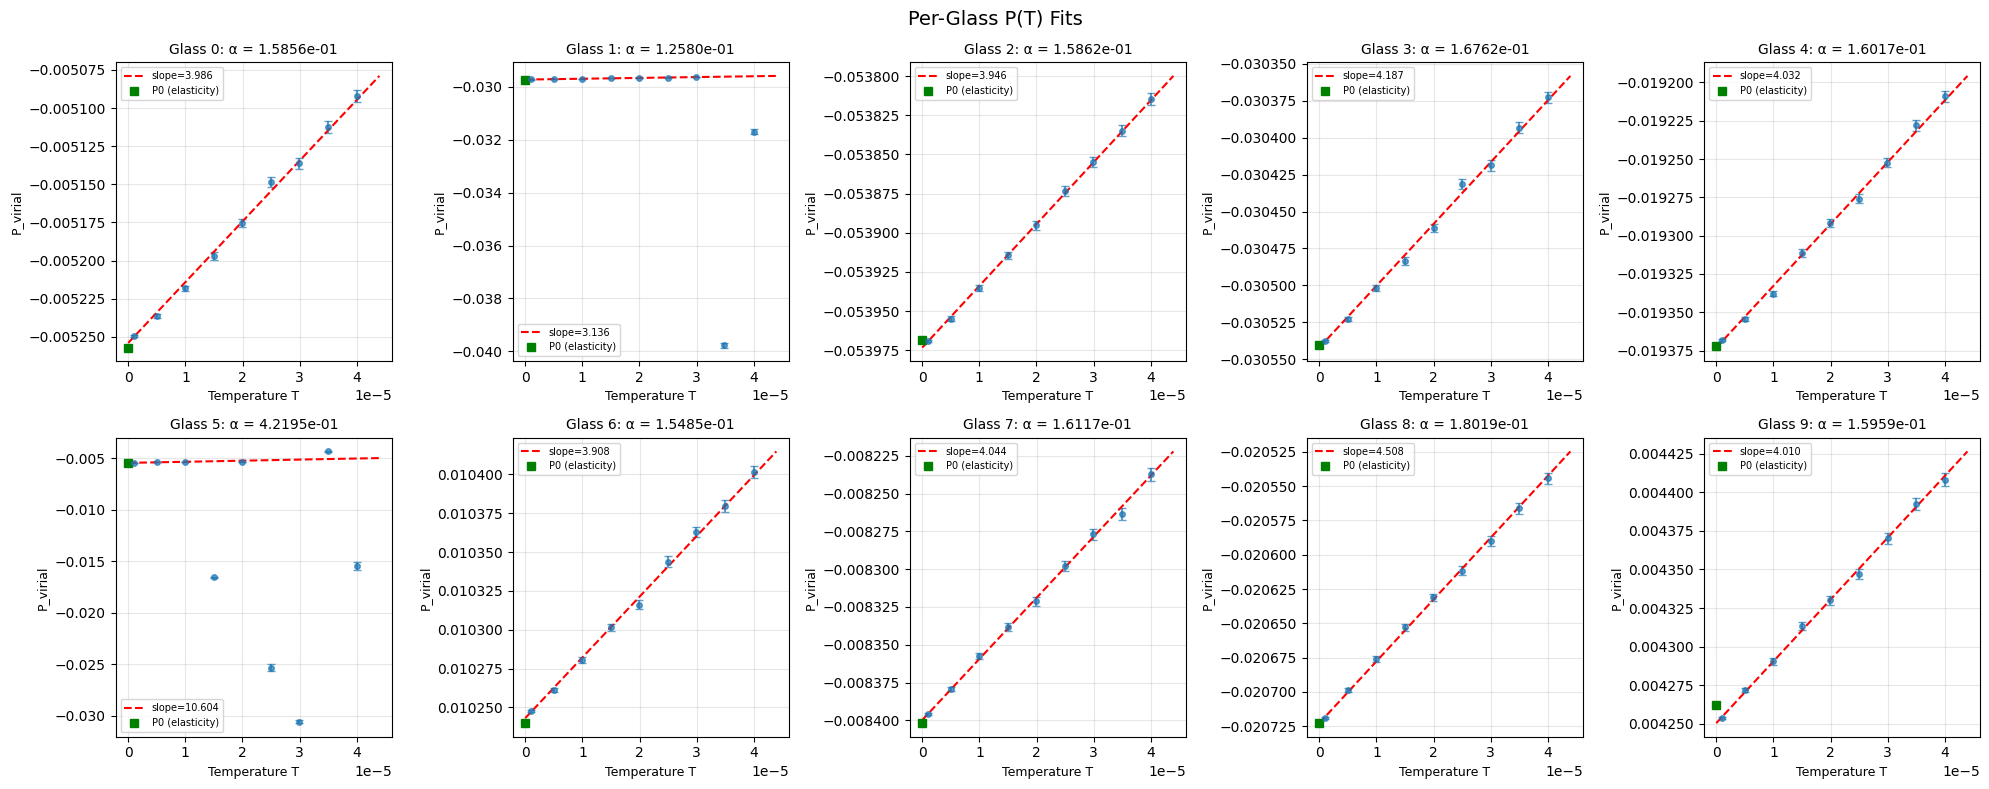

In [61]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for g in GLASSES:
    if g not in pg_fit:
        continue
    
    ax = axes[g]
    
    # Get data
    pts = pg_data[g]
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    
    # Get fit
    P0_fit_g, dPdT_g, _, _ = pg_fit[g]
    
    # Plot
    ax.errorbar(Tv, Pv, yerr=Ev, fmt='o', markersize=4, capsize=3, alpha=0.7)
    T_line = np.linspace(0, Tv.max() * 1.1, 100)
    ax.plot(T_line, P0_fit_g + dPdT_g * T_line, 'r--', lw=1.5,
            label=f'slope={dPdT_g:.3f}')
    ax.plot(0, P0_per_glass[g], 'gs', markersize=6, label='P0 (elasticity)')
    
    ax.set_xlabel('Temperature T', fontsize=9)
    ax.set_ylabel('P_virial', fontsize=9)
    ax.set_title(f'Glass {g}: α = {alpha_numerical[g]:.4e}', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Per-Glass P(T) Fits', fontsize=14)
fig.tight_layout()
plt.show()


## ΔP vs T — Individual Glasses Centered at T=0

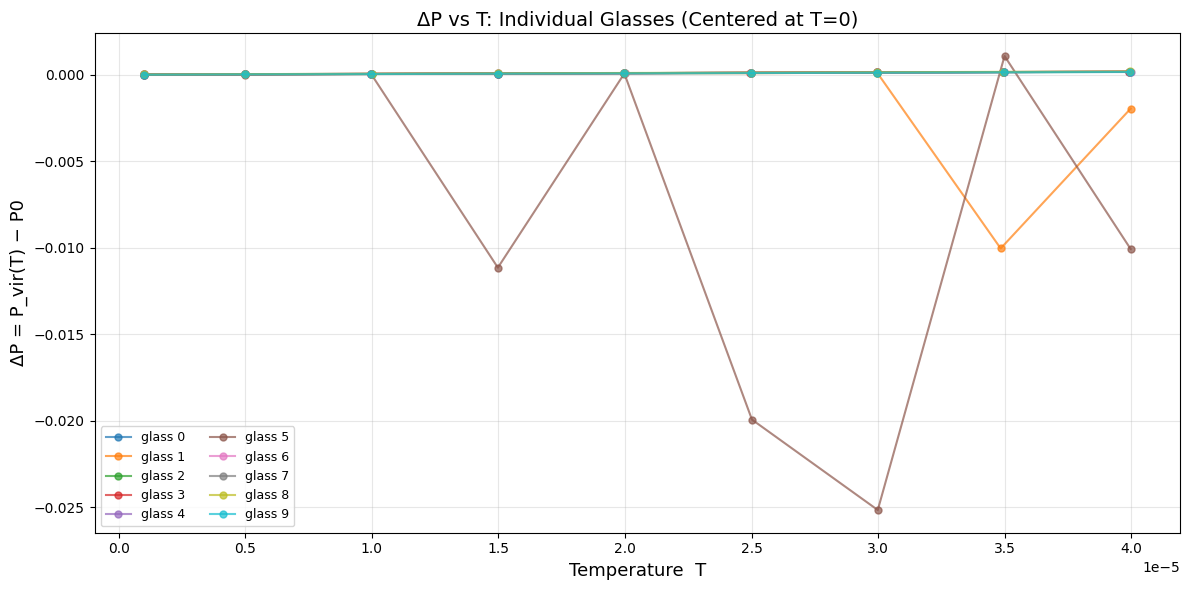

In [62]:
fig, ax = plt.subplots(figsize=(12, 6))

for g in GLASSES:
    if g not in pg_fit:
        continue
    
    pts = pg_data[g]
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    
    # Center at P0
    dP = Pv - P0_per_glass[g]
    
    ax.plot(Tv, dP, 'o-', lw=1.5, markersize=5, alpha=0.7, label=f'glass {g}')

ax.set_xlabel('Temperature  T', fontsize=13)
ax.set_ylabel('ΔP = P_vir(T) − P0', fontsize=13)
ax.set_title('ΔP vs T: Individual Glasses (Centered at T=0)', fontsize=14)
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Alpha Theory — Microscopic Calculation
We now compute $\alpha$ from first principles using the inherent-state formula:

$$\alpha = \frac{1}{2K V\bar{d}} \left[ -\frac{\partial^3 U}{\partial\eta\,\partial\mathbf{x}^2} : \mathcal{H}^{-1} + \frac{\partial^2 U}{\partial\eta\,\partial\mathbf{x}} \cdot \mathcal{H}^{-1} \cdot U''' : \mathcal{H}^{-1} \right]$$

Expanded in the normal-mode basis $\mathcal{H}^{-1} = \sum_\omega \frac{1}{\omega^2}\Psi_\omega\otimes\Psi_\omega$, this becomes:

$$\alpha = -\frac{1}{2KV\bar{d}} \sum_\omega \frac{1}{\omega^2}\left[u_{\eta xx}(\Psi_\omega,\Psi_\omega) + \text{tess}_3(\text{vna}_{\text{file}},\Psi_\omega,\Psi_\omega)\right]$$

### Save per-glass numerical α so `alpha_theory.py` can read it

In [63]:
import os
DATA_DIR_C = "initial_files"

alpha_num_path = os.path.join(DATA_DIR_C, "alpha_numerical.txt")
with open(alpha_num_path, "w") as _f:
    _f.write("# Numerical alpha — per-glass values\n")
    _f.write(f"# Mean alpha = {alpha_num_mean:.12g}  (SEM = {alpha_num_sem:.12g})\n")
    _f.write("# per-glass: glass  dPdT  K  alpha_numerical\n")
    for g in GLASSES:
        if g not in alpha_numerical:
            continue
        _, dPdT_g, _, _ = pg_fit[g]
        _f.write(f"glass_{g}  {dPdT_g:.12g}  {K_per_glass[g]:.12g}  {alpha_numerical[g]:.12g}\n")

print(f"Wrote {alpha_num_path}")
print(f"  alpha_num mean = {alpha_num_mean:+.6e}  ±  {alpha_num_sem:.6e}  (SEM)")
print(f"  alpha_num std  = {alpha_num_std:.6e}")
print(f"  alpha_num per glass:")
for g, av in alpha_numerical.items():
    print(f"    g{g}: {av:+.6e}")


Wrote initial_files/alpha_numerical.txt
  alpha_num mean = +1.848512e-01  ±  2.532018e-02  (SEM)
  alpha_num std  = 8.006944e-02
  alpha_num per glass:
    g0: +1.585592e-01
    g1: +1.257985e-01
    g2: +1.586224e-01
    g3: +1.676210e-01
    g4: +1.601689e-01
    g5: +4.219535e-01
    g6: +1.548517e-01
    g7: +1.611652e-01
    g8: +1.801850e-01
    g9: +1.595863e-01


### Run `alpha_theory.py` (diagonalizes H, caches results)

In [64]:
import subprocess
import sys

cmd = [
    sys.executable,
    f"{DATA_DIR_C}/alpha_theory_FINAL.py",
    "--data-dir", DATA_DIR_C,
    "--cache-dir", f"{DATA_DIR_C}/alpha_cache",
    "--out-dir", DATA_DIR_C,
    "--glasses", "0-9"
]
print(f"Running: {' '.join(cmd)}")
print("-" * 60)
result = subprocess.run(cmd, capture_output=False)


Running: /home/sangam/vsc/astrophy/astrophyenv/bin/python initial_files/alpha_theory_FINAL.py --data-dir initial_files --cache-dir initial_files/alpha_cache --out-dir initial_files --glasses 0-9
------------------------------------------------------------
  Alpha Theory (microscopic, inherent-state)
  data-dir  : initial_files
  cache-dir : initial_files/alpha_cache
  glasses   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[g=0]  K = 25.139476
  [g=0] cache hit -- loading initial_files/alpha_cache/alpha_cache_g0.npz


/home/sangam/vsc/glass_simulations/LJ_glass/attempt_4/initial_files/alpha_theory_FINAL.py:293: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V              = float(cached["V"])


    [g=0] term1 unweighted sum = -3.992150e+07
    [g=0] term2 unweighted sum = +3.324295e+06
  alpha_theory     = +1.855282e-01
    harmonic       = +2.072368e-01
    anharmonic     = -2.170863e-02

[g=1]  K = 24.931039
  [g=1] cache hit -- loading initial_files/alpha_cache/alpha_cache_g1.npz
    [g=1] term1 unweighted sum = -3.986853e+07
    [g=1] term2 unweighted sum = +3.483522e+06
  alpha_theory     = +1.855766e-01
    harmonic       = +2.093617e-01
    anharmonic     = -2.378503e-02

[g=2]  K = 24.875548
  [g=2] cache hit -- loading initial_files/alpha_cache/alpha_cache_g2.npz
    [g=2] term1 unweighted sum = -3.959478e+07
    [g=2] term2 unweighted sum = +3.207243e+06
  alpha_theory     = +1.871793e-01
    harmonic       = +2.097248e-01
    anharmonic     = -2.254555e-02

[g=3]  K = 24.981683
  [g=3] cache hit -- loading initial_files/alpha_cache/alpha_cache_g3.npz
    [g=3] term1 unweighted sum = -3.973807e+07
    [g=3] term2 unweighted sum = +3.309688e+06
  alpha_theory     = 

### Load theory results and compare

In [65]:
results_path = Path(DATA_DIR_C) / 'alpha_theory_results.txt'

if results_path.exists():
    # Parse theory results
    theory_data = {}
    with open(results_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 5 and parts[0].startswith('glass_'):
                g = int(parts[0].split('_')[1])
                theory_data[g] = {
                    'harmonic': float(parts[1]),
                    'anharmonic': float(parts[2]),
                    'total': float(parts[3])
                }
    
    # Extract arrays for plotting
    g_theory = np.array(sorted(theory_data.keys()))
    alpha_harm_arr = np.array([theory_data[g]['harmonic'] for g in g_theory])
    alpha_anharm_arr = np.array([theory_data[g]['anharmonic'] for g in g_theory])
    alpha_theory_arr = np.array([theory_data[g]['total'] for g in g_theory])
    
    alpha_theory_mean = alpha_theory_arr.mean()
    alpha_theory_std = alpha_theory_arr.std()
    alpha_theory_sem = alpha_theory_std / np.sqrt(len(alpha_theory_arr))
    
    print("\nTheory Results Loaded:")
    print(f"  Mean alpha_theory = {alpha_theory_mean:+.6e}  ±  {alpha_theory_sem:.6e}  (SEM)")
    print(f"  Std  alpha_theory = {alpha_theory_std:.6e}")
else:
    print(f"Warning: {results_path} not found. Run alpha_theory.py first.")



Theory Results Loaded:
  Mean alpha_theory = +1.860398e-01  ±  4.051282e-04  (SEM)
  Std  alpha_theory = 1.281128e-03


### Comprehensive comparison plot

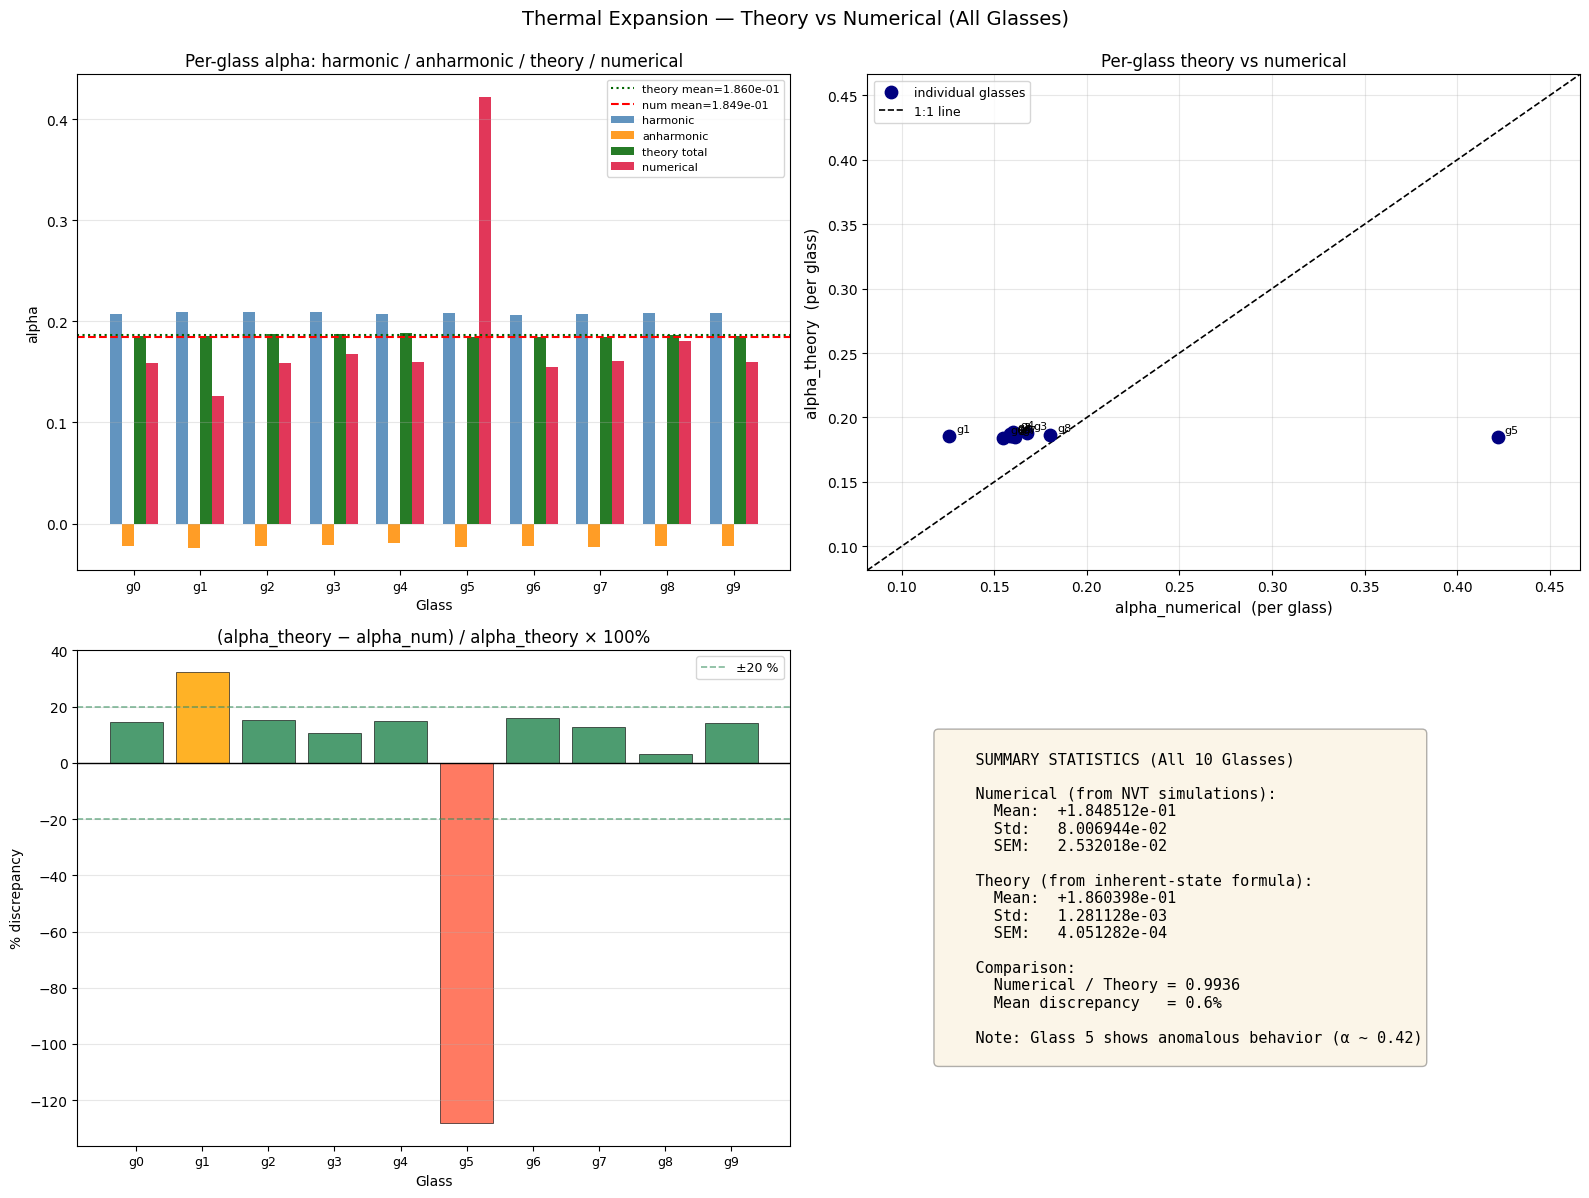

Saved alpha_comparison_all_glasses.png


In [66]:
if results_path.exists():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    #  Panel 1 (top-left): Per-glass bars — 4 series 
    ax = axes[0, 0]
    x  = np.arange(len(g_theory))
    bw = 0.18
    an_arr_ordered = np.array([alpha_numerical.get(int(g), np.nan) for g in g_theory])
    ax.bar(x - 1.5*bw, alpha_harm_arr,   bw, label='harmonic',     color='steelblue',  alpha=0.85)
    ax.bar(x - 0.5*bw, alpha_anharm_arr, bw, label='anharmonic',   color='darkorange', alpha=0.85)
    ax.bar(x + 0.5*bw, alpha_theory_arr, bw, label='theory total', color='darkgreen',  alpha=0.85)
    ax.bar(x + 1.5*bw, an_arr_ordered,   bw, label='numerical',    color='crimson',    alpha=0.85)
    ax.axhline(alpha_theory_mean, color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={alpha_theory_mean:.3e}')
    ax.axhline(alpha_num_mean, color='red', ls='--', lw=1.5,
                label=f'num mean={alpha_num_mean:.3e}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'g{int(g)}' for g in g_theory], fontsize=9)
    ax.set_xlabel('Glass')
    ax.set_ylabel('alpha')
    ax.set_title('Per-glass alpha: harmonic / anharmonic / theory / numerical')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    #  Panel 2 (top-right): Theory vs numerical scatter 
    ax2 = axes[0, 1]
    an_vals = np.array([alpha_numerical.get(int(g), np.nan) for g in g_theory])
    valid   = ~np.isnan(an_vals)
    ax2.scatter(an_vals[valid], alpha_theory_arr[valid], color='navy', s=80, zorder=3,
                label='individual glasses')
    for i, g in enumerate(g_theory):
        if valid[i]:
            ax2.annotate(f'g{int(g)}', (an_vals[i], alpha_theory_arr[i]),
                        textcoords='offset points', xytext=(5, 3), fontsize=8)
    all_vals = np.concatenate([an_vals[valid], alpha_theory_arr[valid]])
    pad  = (all_vals.max() - all_vals.min()) * 0.15
    lims = (all_vals.min() - pad, all_vals.max() + pad)
    ax2.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    ax2.set_xlim(lims)
    ax2.set_ylim(lims)
    ax2.set_xlabel('alpha_numerical  (per glass)', fontsize=11)
    ax2.set_ylabel('alpha_theory  (per glass)', fontsize=11)
    ax2.set_title('Per-glass theory vs numerical')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    
    #  Panel 3 (bottom-left): Per-glass % discrepancy 
    ax3 = axes[1, 0]
    discs, valid_idx = [], []
    for i, g in enumerate(g_theory):
        g_int = int(g)
        if g_int in alpha_numerical and not np.isnan(an_vals[i]):
            disc_pct = (alpha_theory_arr[i] - an_vals[i]) / abs(alpha_theory_arr[i]) * 100
            discs.append(disc_pct)
            valid_idx.append(i)
    discs     = np.array(discs)
    valid_idx = np.array(valid_idx)
    bar_cols  = ['seagreen' if abs(d) < 20 else 'orange' if abs(d) < 50 else 'tomato'
                 for d in discs]
    ax3.bar(valid_idx, discs, color=bar_cols, alpha=0.85, edgecolor='black', lw=0.5)
    ax3.axhline(0,    color='black',    lw=1.0)
    ax3.axhline( 20,  color='seagreen', ls='--', lw=1.2, alpha=0.6, label='±20 %')
    ax3.axhline(-20,  color='seagreen', ls='--', lw=1.2, alpha=0.6)
    ax3.set_xticks(valid_idx)
    ax3.set_xticklabels([f'g{int(g_theory[i])}' for i in valid_idx], fontsize=9)
    ax3.set_xlabel('Glass')
    ax3.set_ylabel('% discrepancy')
    ax3.set_title('(alpha_theory − alpha_num) / alpha_theory × 100%')
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    #  Panel 4 (bottom-right): Summary statistics
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    summary_text = f"""
    SUMMARY STATISTICS (All 10 Glasses)
    
    Numerical (from NVT simulations):
      Mean:  {alpha_num_mean:+.6e}
      Std:   {alpha_num_std:.6e}
      SEM:   {alpha_num_sem:.6e}
    
    Theory (from inherent-state formula):
      Mean:  {alpha_theory_mean:+.6e}
      Std:   {alpha_theory_std:.6e}
      SEM:   {alpha_theory_sem:.6e}
    
    Comparison:
      Numerical / Theory = {alpha_num_mean / alpha_theory_mean:.4f}
      Mean discrepancy   = {np.nanmean(discs):.1f}%
    
    Note: Glass 5 shows anomalous behavior (α ~ 0.42)
    """
    
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    fig.suptitle('Thermal Expansion — Theory vs Numerical (All Glasses)', fontsize=14, y=0.995)
    fig.tight_layout()
    plt.savefig(Path(DATA_DIR_C) / 'alpha_comparison_all_glasses.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved alpha_comparison_all_glasses.png")


---
## Clean Analysis: Exclude Outliers

Glass 5 shows anomalous behavior. Let's recompute statistics excluding outliers.

In [67]:
# Identify outliers (more than 2 std from mean)
threshold = 2.0
outliers = []
for g, alpha_g in alpha_numerical.items():
    if abs(alpha_g - alpha_num_mean) > threshold * alpha_num_std:
        outliers.append(g)
        print(f"Glass {g} is an outlier: α = {alpha_g:.6e} (mean ± {threshold}σ = {alpha_num_mean:.6e} ± {threshold * alpha_num_std:.6e})")

# Clean datasets
GLASSES_CLEAN = [g for g in GLASSES if g not in outliers]
print(f"\nCleaned dataset: excluding glasses {outliers}")
print(f"Remaining glasses: {GLASSES_CLEAN}")

# Recompute statistics
alpha_clean = [alpha_numerical[g] for g in GLASSES_CLEAN if g in alpha_numerical]
alpha_mean_c = np.mean(alpha_clean)
alpha_std_c = np.std(alpha_clean)
alpha_sem_c = alpha_std_c / np.sqrt(len(alpha_clean))

print(f"\nCleaned statistics:")
print(f"  Mean alpha = {alpha_mean_c:+.6e}  ±  {alpha_sem_c:.6e}  (SEM)")
print(f"  Std  alpha = {alpha_std_c:.6e}")

if results_path.exists():
    alpha_theory_clean = [alpha_theory_arr[list(g_theory).index(g)] for g in GLASSES_CLEAN if g in g_theory]
    at_mean_c = np.mean(alpha_theory_clean)
    at_std_c = np.std(alpha_theory_clean)
    at_sem_c = at_std_c / np.sqrt(len(alpha_theory_clean))
    
    print(f"\nTheory (cleaned):")
    print(f"  Mean alpha_theory = {at_mean_c:+.6e}  ±  {at_sem_c:.6e}  (SEM)")
    print(f"  Std  alpha_theory = {at_std_c:.6e}")
    print(f"\nNumerical / Theory = {alpha_mean_c / at_mean_c:.4f}")


Glass 5 is an outlier: α = 4.219535e-01 (mean ± 2.0σ = 1.848512e-01 ± 1.601389e-01)

Cleaned dataset: excluding glasses [5]
Remaining glasses: [0, 1, 2, 3, 4, 6, 7, 8, 9]

Cleaned statistics:
  Mean alpha = +1.585065e-01  ±  4.509552e-03  (SEM)
  Std  alpha = 1.352866e-02

Theory (cleaned):
  Mean alpha_theory = +1.861639e-01  ±  4.306859e-04  (SEM)
  Std  alpha_theory = 1.292058e-03

Numerical / Theory = 0.8514


### Final comparison plot (cleaned data)

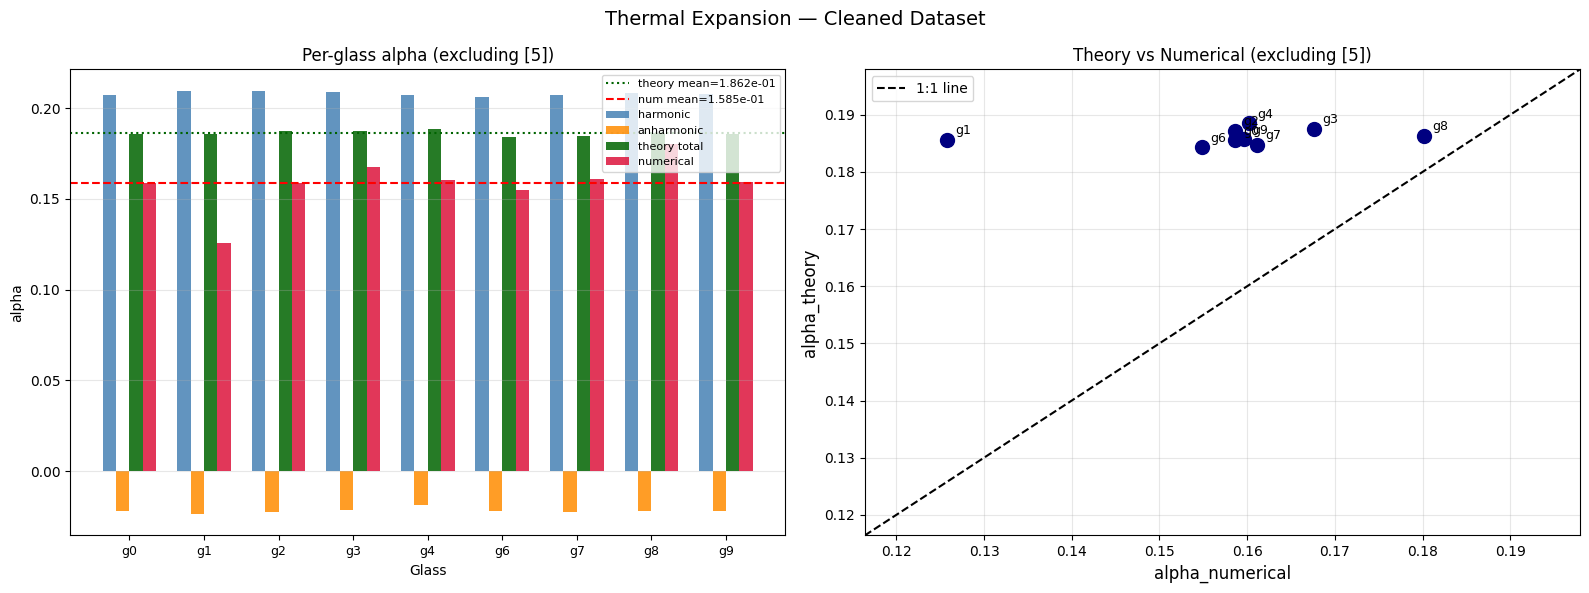

Saved alpha_comparison_cleaned.png


In [68]:
if results_path.exists():
    # Get clean theory data
    g_th_c = np.array([g for g in g_theory if g in GLASSES_CLEAN])
    ah_c = np.array([theory_data[g]['harmonic'] for g in g_th_c])
    aa_c = np.array([theory_data[g]['anharmonic'] for g in g_th_c])
    at_c = np.array([theory_data[g]['total'] for g in g_th_c])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel 1: Bar plot
    ax = axes[0]
    x_c = np.arange(len(g_th_c))
    bw = 0.18
    an_ord_c = np.array([alpha_numerical.get(int(g), np.nan) for g in g_th_c])
    ax.bar(x_c - 1.5*bw, ah_c,    bw, label='harmonic',     color='steelblue',  alpha=0.85)
    ax.bar(x_c - 0.5*bw, aa_c,    bw, label='anharmonic',   color='darkorange', alpha=0.85)
    ax.bar(x_c + 0.5*bw, at_c,    bw, label='theory total', color='darkgreen',  alpha=0.85)
    ax.bar(x_c + 1.5*bw, an_ord_c, bw, label='numerical',   color='crimson',    alpha=0.85)
    ax.axhline(at_mean_c,    color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={at_mean_c:.3e}')
    ax.axhline(alpha_mean_c, color='red',        ls='--', lw=1.5,
                label=f'num mean={alpha_mean_c:.3e}')
    ax.set_xticks(x_c)
    ax.set_xticklabels([f'g{int(g)}' for g in g_th_c], fontsize=9)
    ax.set_xlabel('Glass')
    ax.set_ylabel('alpha')
    ax.set_title(f'Per-glass alpha (excluding {outliers})')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Panel 2: Scatter plot
    ax2 = axes[1]
    valid_c = ~np.isnan(an_ord_c)
    ax2.scatter(an_ord_c[valid_c], at_c[valid_c], color='navy', s=100, zorder=3)
    for i, g in enumerate(g_th_c):
        if valid_c[i]:
            ax2.annotate(f'g{int(g)}', (an_ord_c[i], at_c[i]),
                        textcoords='offset points', xytext=(6, 4), fontsize=9)
    all_v = np.concatenate([an_ord_c[valid_c], at_c[valid_c]])
    pad = (all_v.max() - all_v.min()) * 0.15
    lims = (all_v.min() - pad, all_v.max() + pad)
    ax2.plot(lims, lims, 'k--', lw=1.5, label='1:1 line')
    ax2.set_xlim(lims)
    ax2.set_ylim(lims)
    ax2.set_xlabel('alpha_numerical', fontsize=12)
    ax2.set_ylabel('alpha_theory', fontsize=12)
    ax2.set_title(f'Theory vs Numerical (excluding {outliers})')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)
    
    fig.suptitle('Thermal Expansion — Cleaned Dataset', fontsize=14)
    fig.tight_layout()
    plt.savefig(Path(DATA_DIR_C) / 'alpha_comparison_cleaned.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved alpha_comparison_cleaned.png")


## Final Summary

In [69]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print()
print("ALL GLASSES (n=10):")
print(f"  Numerical: α = {alpha_num_mean:+.6e} ± {alpha_num_sem:.6e} (SEM)")
print(f"             σ = {alpha_num_std:.6e}")
if results_path.exists():
    print(f"  Theory:    α = {alpha_theory_mean:+.6e} ± {alpha_theory_sem:.6e} (SEM)")
    print(f"             σ = {alpha_theory_std:.6e}")
    print(f"  Ratio (Num/Theory): {alpha_num_mean / alpha_theory_mean:.4f}")
print()
print(f"CLEANED DATASET (n={len(GLASSES_CLEAN)}, excluding {outliers}):")
print(f"  Numerical: α = {alpha_mean_c:+.6e} ± {alpha_sem_c:.6e} (SEM)")
print(f"             σ = {alpha_std_c:.6e}")
if results_path.exists():
    print(f"  Theory:    α = {at_mean_c:+.6e} ± {at_sem_c:.6e} (SEM)")
    print(f"             σ = {at_std_c:.6e}")
    print(f"  Ratio (Num/Theory): {alpha_mean_c / at_mean_c:.4f}")
print("="*70)


FINAL SUMMARY

ALL GLASSES (n=10):
  Numerical: α = +1.848512e-01 ± 2.532018e-02 (SEM)
             σ = 8.006944e-02
  Theory:    α = +1.860398e-01 ± 4.051282e-04 (SEM)
             σ = 1.281128e-03
  Ratio (Num/Theory): 0.9936

CLEANED DATASET (n=9, excluding [5]):
  Numerical: α = +1.585065e-01 ± 4.509552e-03 (SEM)
             σ = 1.352866e-02
  Theory:    α = +1.861639e-01 ± 4.306859e-04 (SEM)
             σ = 1.292058e-03
  Ratio (Num/Theory): 0.8514
